## Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings

warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.linear_model import LinearRegression

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX



## Загрузка данных

In [2]:
df = pd.read_csv("./data/data.csv", sep=";", decimal=",")

In [3]:
df_without_gaps = df[df["x4"] != " "].copy()

# Месяцы
months = df_without_gaps["date1"]

# Год
years = df_without_gaps["date2"]

time_series = df_without_gaps['x4'].astype(str).str.replace(',', '.').astype(float)

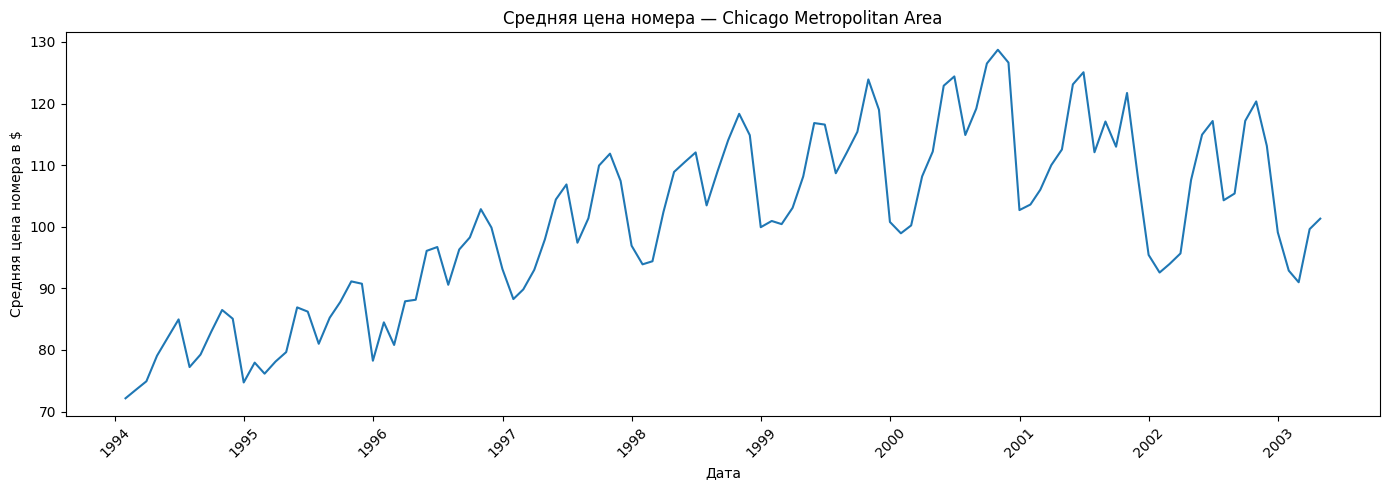

In [4]:
df_without_gaps['date'] = pd.date_range(start='1994-01', periods=len(df_without_gaps), freq='ME')

plt.figure(figsize=(14, 5))
sns.lineplot(x=df_without_gaps['date'] , y=time_series)

plt.title('Средняя цена номера — Chicago Metropolitan Area')
plt.xlabel('Дата')
plt.ylabel('Средняя цена номера в $')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Seasonal decomposition

In [5]:
seasonal_decomposition_result = seasonal_decompose(time_series, model="multiplicative", period=12)
time_series_without_seasonal = time_series / seasonal_decomposition_result.seasonal

# Значения тренда без nan's
trend_without_nans = seasonal_decomposition_result.trend.dropna()

# Формируем новый DataFrame
new_trend_df = pd.DataFrame({
    "trend": trend_without_nans,
    "month_num": np.arange(13, 13 + len(trend_without_nans)),
}).reset_index().drop("index", axis=1)

# Вглянем на новый DataFrame
new_trend_df

new_trend_df["month_num_squared"] = new_trend_df["month_num"] ** 2
new_trend_df["month_num_cubed"] = new_trend_df["month_num"] ** 3

# Таргет
y = new_trend_df["trend"]

# Первый вариант - используем только month_num
X1 = new_trend_df[["month_num"]]

# Второй вариант - используем month_num и month_num в квадрате
X2 = new_trend_df[["month_num", "month_num_squared"]]

# Третий вариант - используем month_num, month_num в квадрате, month_num в кубе
X3 = new_trend_df[["month_num", "month_num_squared", "month_num_cubed"]]

# Обучаем линейную регрессию на первом датасете фичей
first_model = LinearRegression().fit(X1, y)

# Обучаем линейную регрессию на втором датасете фичей
second_model = LinearRegression().fit(X2, y)

# Обучаем линейную регрессию на третьем датасете фичей
third_model = LinearRegression().fit(X3, y)

X_forestcast = pd.DataFrame(
    {
        "month_num": np.arange(new_trend_df["month_num"].iloc[-1] + 1, new_trend_df["month_num"].iloc[-1] + 1 + 8)
    }
)

# Добавим month_num^2

X_forestcast["month_num_squared"] = X_forestcast["month_num"] ** 2

forecast_without_seasonality = second_model.predict(X_forestcast)
forecast_with_seasonality = forecast_without_seasonality * seasonal_decomposition_result.seasonal.iloc[4:4+8].values

## Exponential smoothing

In [6]:
exp_smooth = ExponentialSmoothing(
    time_series, 
    trend="additive",
    damped_trend=True,
    seasonal="multiplicative",
    seasonal_periods=12,
    initialization_method=None,   
).fit()

predicted_series = exp_smooth.predict(start=0, end=len(time_series) + 7)

## ARIMA

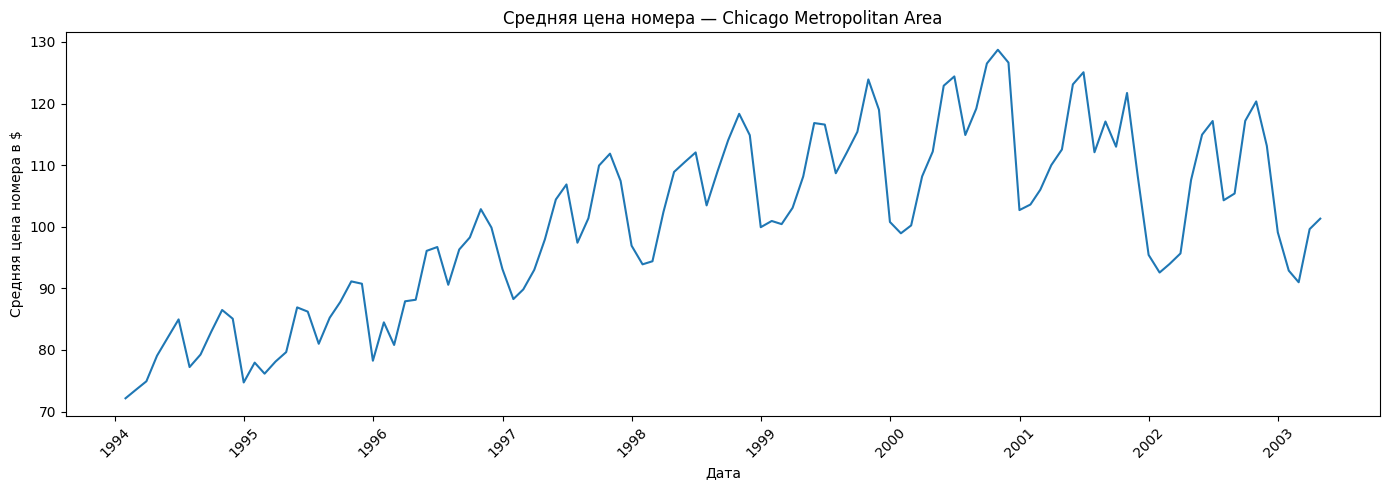

In [7]:
plt.figure(figsize=(14, 5))
sns.lineplot(x=df_without_gaps['date'] , y=time_series)

plt.title('Средняя цена номера — Chicago Metropolitan Area')
plt.xlabel('Дата')
plt.ylabel('Средняя цена номера в $')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

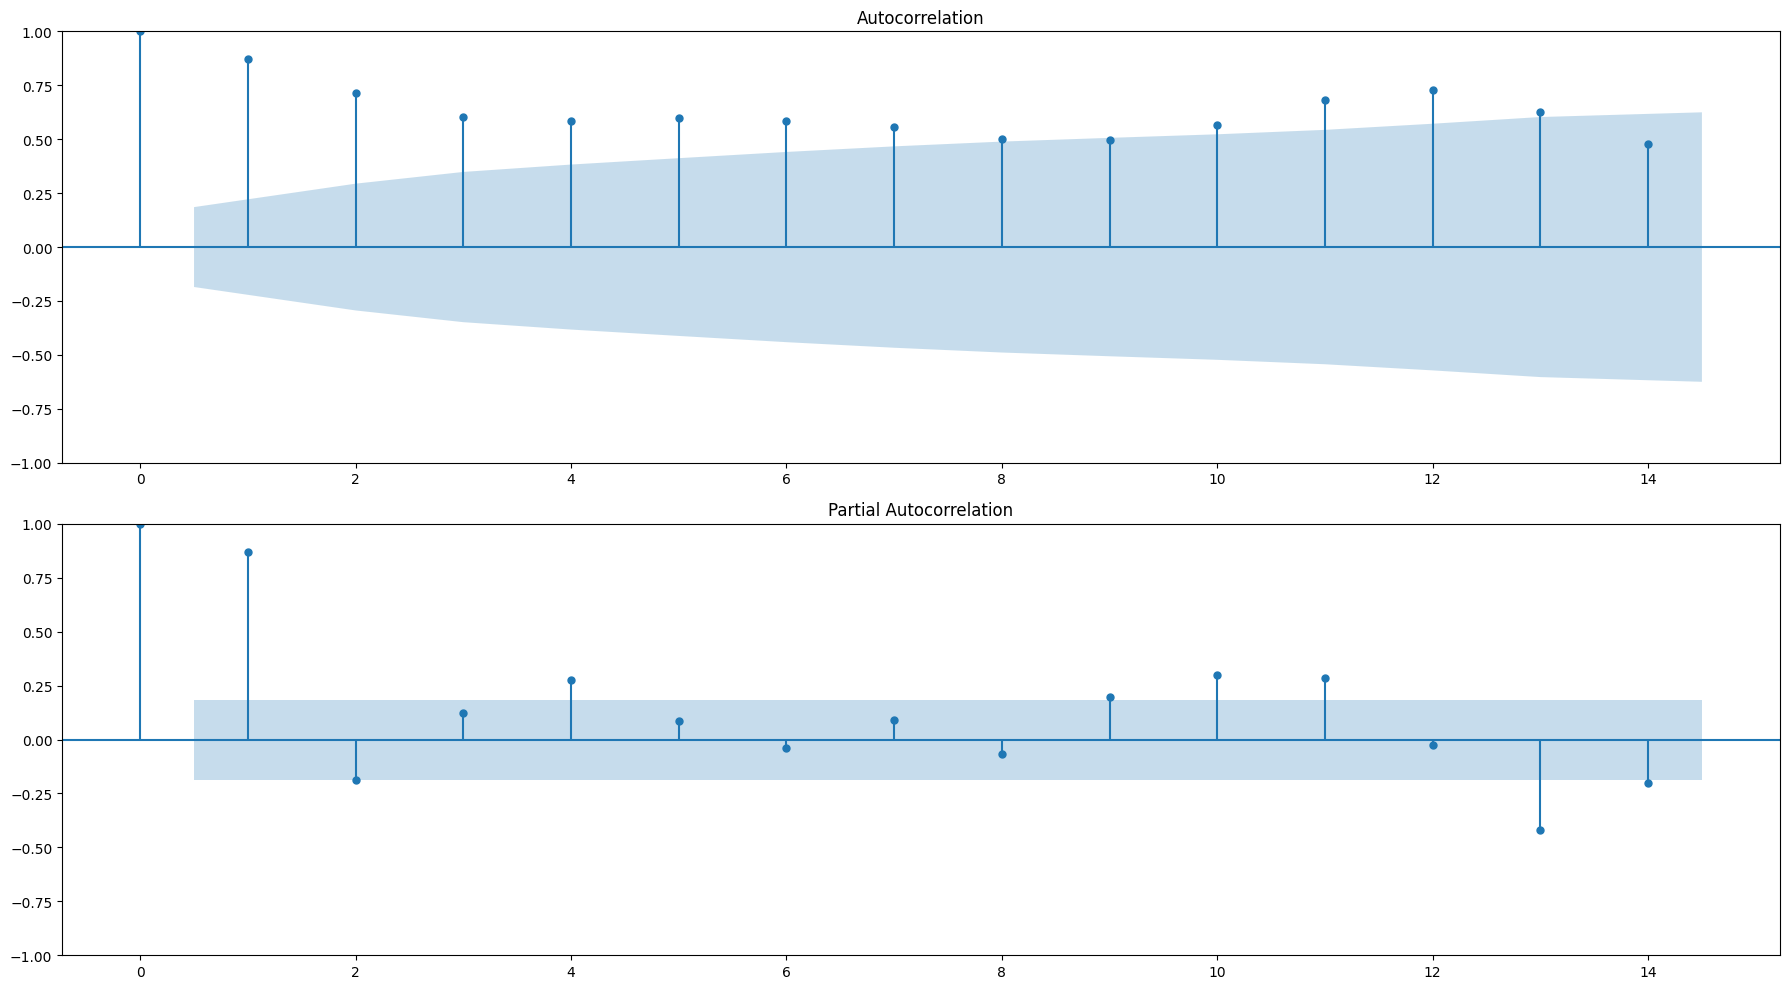

In [8]:
plt.figure(figsize=(18, 10))
plt.subplot(211)
plot_acf(time_series, lags=14, ax=plt.gca())
plt.subplot(212)
plot_pacf(time_series, method="ywmle", lags=14, ax=plt.gca())
plt.tight_layout()
plt.show()

Медленное убывание автокорреляционной функции указывает нам, что необходимо сделать разность.

In [9]:
from copy import deepcopy

cur_time_series = deepcopy(time_series)

In [10]:
cur_time_series = cur_time_series.diff().dropna()

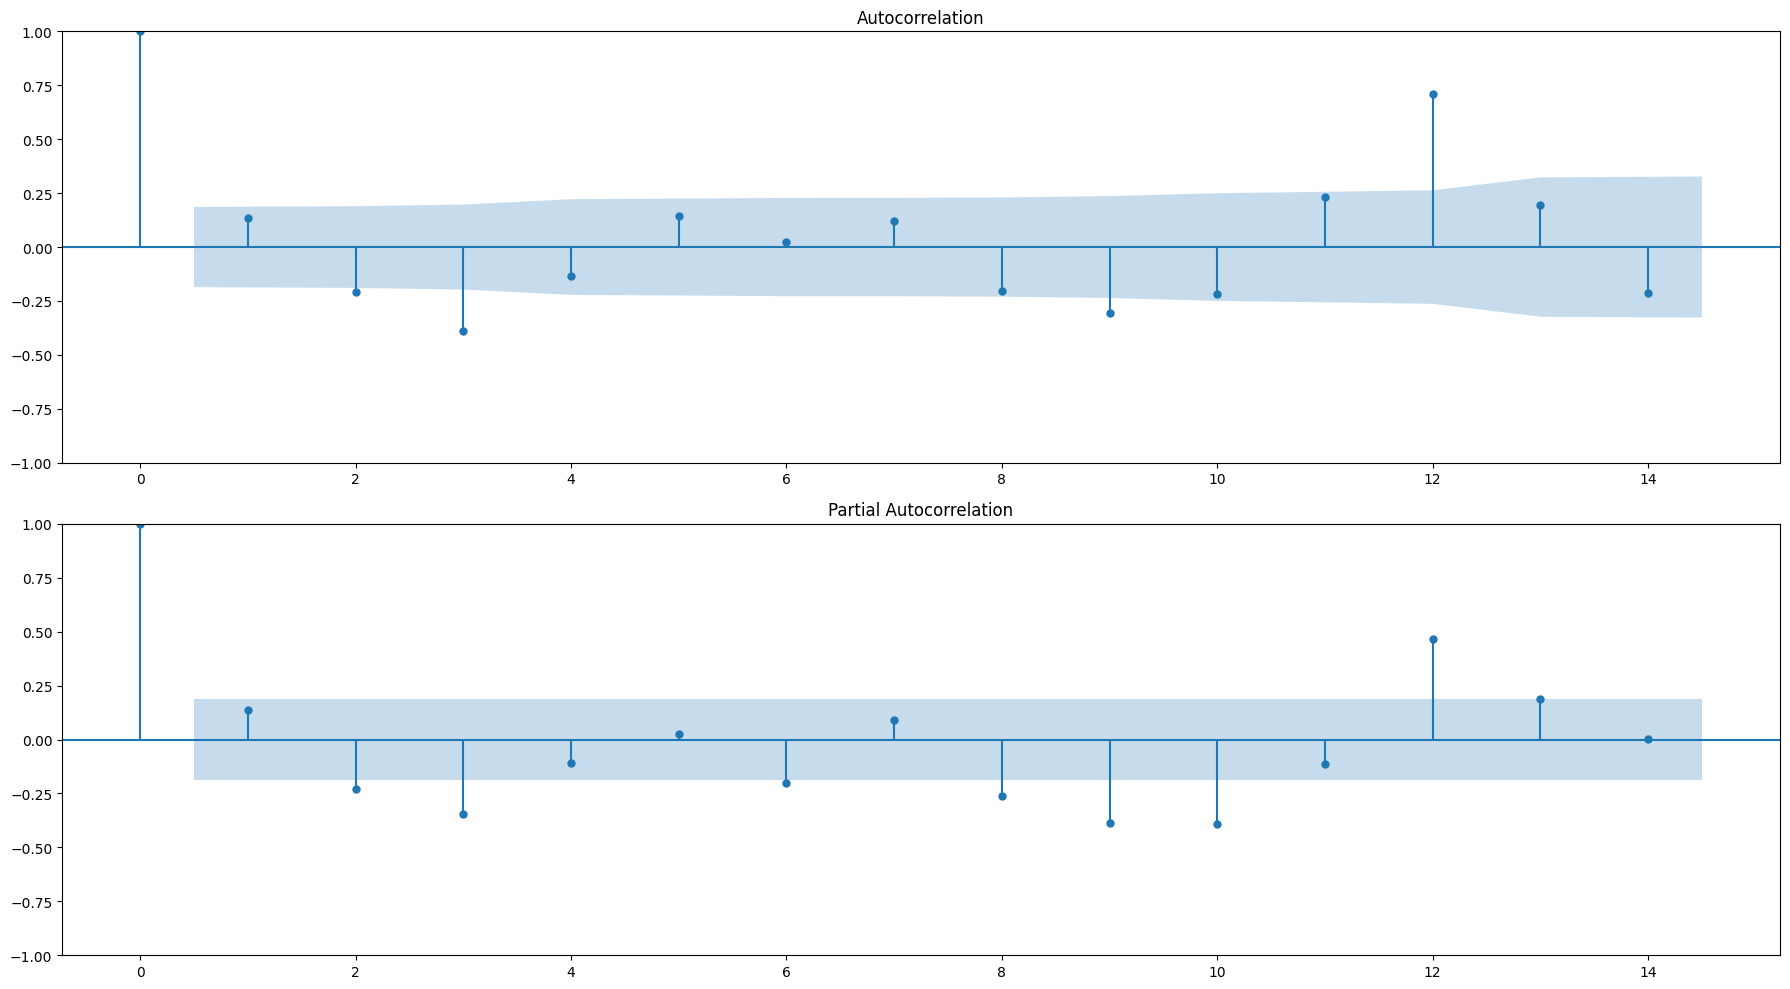

In [11]:
plt.figure(figsize=(18, 10))
plt.subplot(211)
plot_acf(cur_time_series, lags=14, ax=plt.gca())
plt.subplot(212)
plot_pacf(cur_time_series, method="ywmle", lags=14, ax=plt.gca())
plt.tight_layout()
plt.show()

После взятия разностей один раз мы уже получили похожий на стационарный ряд

ACF: большинство лагов находится в пределах доверительного интервала, нет монотонного убывания как раньше 

PACF: то же самое

Может быть сезонная составляющая, но поскольку мы работаем с ARIMA, а не с SARIMA - не смотрим на это.

In [12]:
best_aic = np.inf
best_order = None
results = []

for p, q in itertools.product(range(4), range(4)):
    try:
        m = ARIMA(time_series, order=(p, 1, q)).fit()
        results.append((p, 1, q, m.aic, m.bic))
        if m.aic < best_aic:
            best_aic = m.aic
            best_order = (p, 1, q)
    except:
        continue

print(f'Лучший порядок: {best_order}, AIC: {best_aic:.2f}')

# Топ-5 моделей
results_df = pd.DataFrame(results, columns=['p','d','q','AIC','BIC'])
print(results_df.sort_values('AIC').head())

Лучший порядок: (2, 1, 2), AIC: 702.60
    p  d  q         AIC         BIC
10  2  1  2  702.595434  716.143085
15  3  1  3  714.639090  733.605801
3   0  1  3  718.754082  729.592203
11  2  1  3  720.126772  736.383954
7   1  1  3  720.440015  733.987666


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Обучаем модель с выбранными параметрами

In [13]:
best_model_fitted = ARIMA(time_series, order=(2, 1, 2)).fit()
print(best_model_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                     x4   No. Observations:                  112
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -346.298
Date:                Fri, 15 May 2026   AIC                            702.595
Time:                        17:49:33   BIC                            716.143
Sample:                             0   HQIC                           708.091
                                - 112                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0052      0.026     38.491      0.000       0.954       1.056
ar.L2         -0.9852      0.023    -42.206      0.000      -1.031      -0.939
ma.L1         -1.1133      1.785     -0.624      0.5

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
forecast_steps = 8
forecast_arima = best_model_fitted.forecast(steps=forecast_steps)
print(forecast_arima)

112    100.384591
113     94.661400
114     89.830099
115     90.612141
116     96.157942
117    100.962031
118    100.327396
119     94.956574
Name: predicted_mean, dtype: float64


In [18]:
# best_model_fitted.resid

Построим график автокорреляции и график частной автокорреляции для residuals

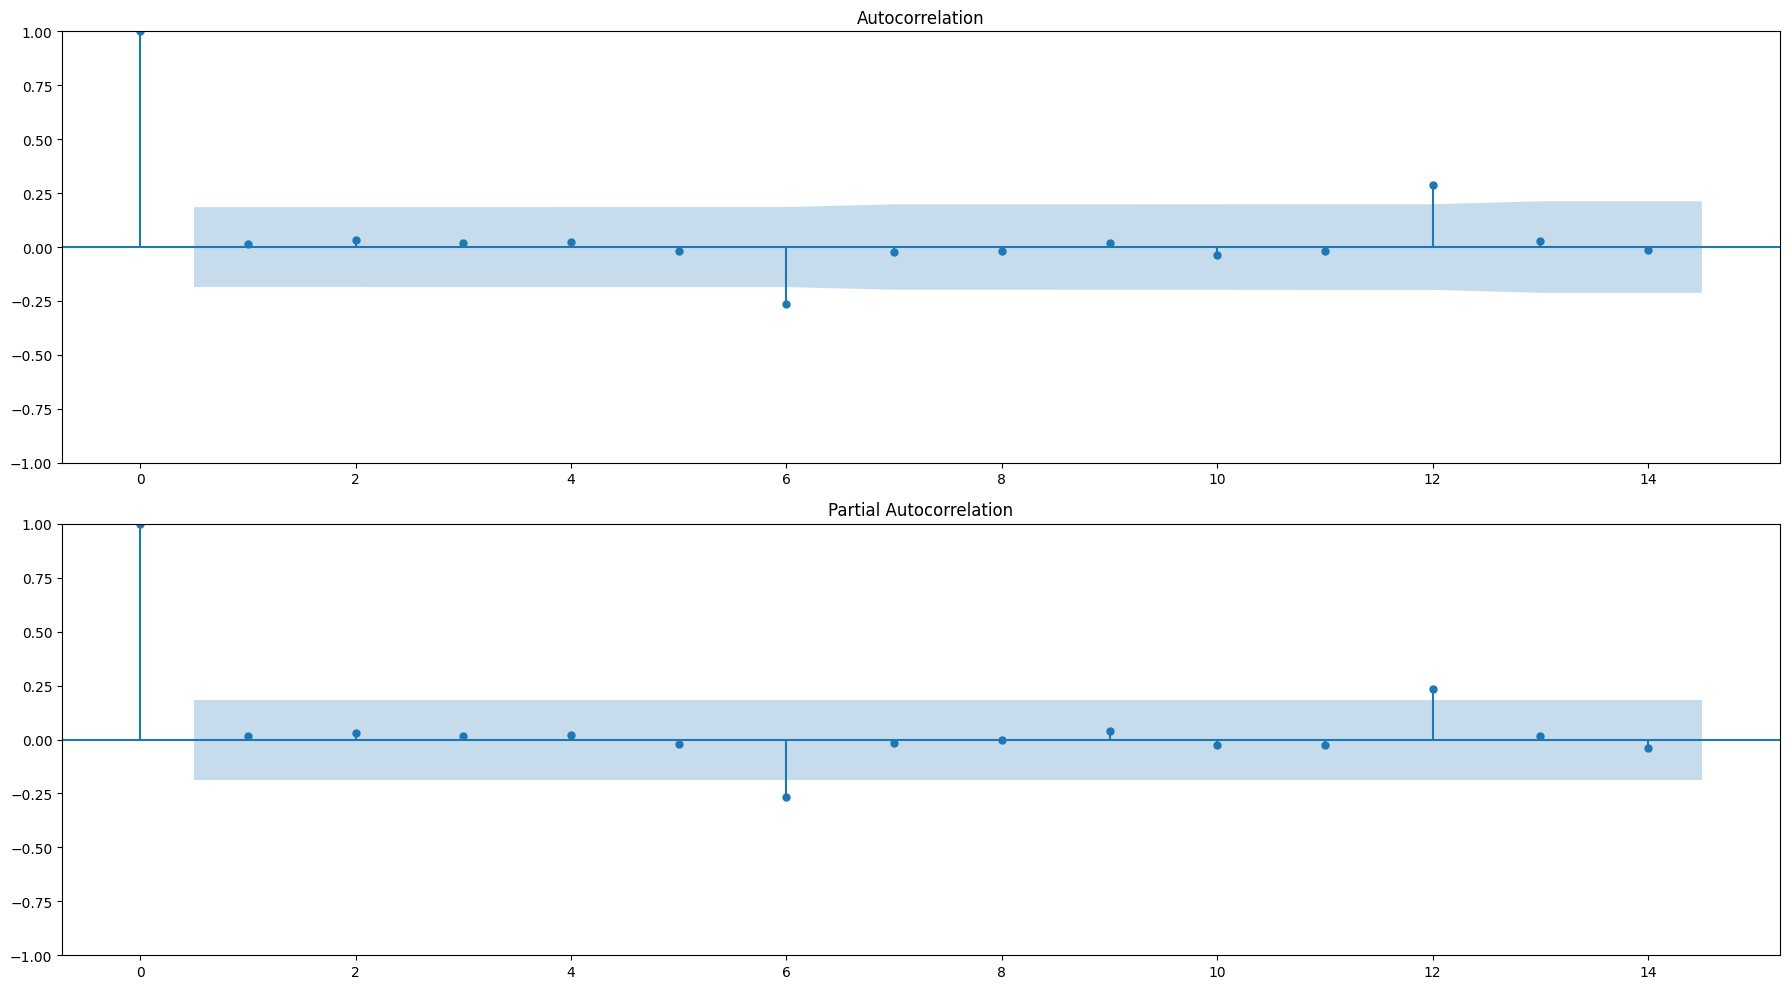

In [17]:
plt.figure(figsize=(18, 10))
plt.subplot(211)
plot_acf(best_model_fitted.resid, lags=14, ax=plt.gca())
plt.subplot(212)
plot_pacf(best_model_fitted.resid, method="ywmle", lags=14, ax=plt.gca())
plt.tight_layout()
plt.show()

- Остатки - белый шум почти, невозможно особо ничего лишнего извлечь

## Строим графики всех прогнозов (seasonal_decomposition, exponential smoothing, ARIMA)

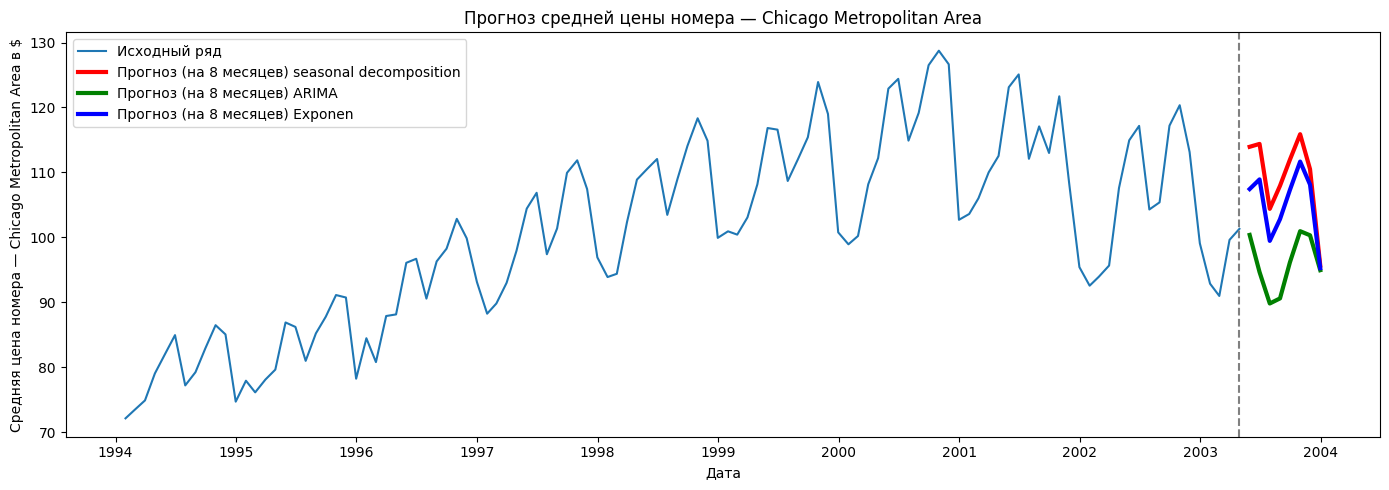

In [15]:
forecast_dates = pd.date_range(start='2003-05', periods=8, freq='ME')

plt.figure(figsize=(14, 5))
plt.plot(df_without_gaps['date'], time_series.values, label='Исходный ряд')
plt.plot(forecast_dates, forecast_with_seasonality, color='red', label='Прогноз (на 8 месяцев) seasonal decomposition', linewidth=3)
plt.plot(forecast_dates, forecast_arima, color='green', label='Прогноз (на 8 месяцев) ARIMA', linewidth=3)
plt.plot(forecast_dates, predicted_series[-8:], color='blue', label='Прогноз (на 8 месяцев) Exponen', linewidth=3)
plt.axvline(x=df_without_gaps['date'].iloc[-1], color='gray', linestyle='--')
plt.title('Прогноз средней цены номера — Chicago Metropolitan Area')
plt.xlabel('Дата')
plt.ylabel('Средняя цена номера — Chicago Metropolitan Area в $')
plt.legend()
plt.tight_layout()
plt.show()

- Seasonal Decomposition (красный цвет) и Exponential Smoothing (синий цвет) предсказывают восстановление цен с сезонными колебаниями около 95–115, ARIMA (зелёный цвет) дает более пессимистичный прогноз с большей амплитудой колебаний, опускаясь меньше 90.
  
- Модель ARIMA работает только с автокорреляционной структурой и смотрит только на предыдущие значения и ошибки. И не учитывает сезонность. Seasonal decomposition метод учитывает сезонность, Exponential smoothing также. Поэтому они имеют более высокий прогноз.

  

In [ ]:
sarima_model_fitted = SARIMAX(time_series,
                order=(2, 1, 2),
                seasonal_order=(1, 0, 1, 12)).fit()
# print(sarima_model_fitted.summary())

sarima_forecast = sarima_model_fitted.forecast(steps=8)

In [ ]:
forecast_dates = pd.date_range(start='2003-05', periods=8, freq='ME')

plt.figure(figsize=(14, 5))
plt.plot(df_without_gaps['date'], time_series.values, label='Исходный ряд')
plt.plot(forecast_dates, forecast_with_seasonality, color='red', label='Прогноз (на 8 месяцев) seasonal decomposition', linewidth=3)
plt.plot(forecast_dates, forecast_arima, color='green', label='Прогноз (на 8 месяцев) ARIMA', linewidth=3)
plt.plot(forecast_dates, predicted_series[-8:], color='blue', label='Прогноз (на 8 месяцев) Exponen', linewidth=3)
plt.axvline(x=df_without_gaps['date'].iloc[-1], color='gray', linestyle='--')
plt.title('Прогноз средней цены номера — Chicago Metropolitan Area')
plt.xlabel('Дата')
plt.ylabel('Средняя цена номера — Chicago Metropolitan Area в $')
plt.legend()
plt.tight_layout()
plt.show()